# Controls with structure: bang-bang and switching

*Introduction to Control and Machine Learning · Part I: Control · Notebook 04*

> **Central question.** *How do the structure of the admissible controls and the choice of cost determine the qualitative structure of an optimal control?*

| | |
|---|---|
| **Estimated reading time** (an estimate, not a measurement with students) | CORE ≈ 50–65 min · DEEPER LOOK and RESEARCH WINDOW ≈ 15 min more |
| **Execution time** | a few seconds |
| **Exercises** | 5 exercises, ≈ 60–100 min |
| **Prerequisites** | [notebook 03](03_observability_duality_adjoints.ipynb): duality identity, condition (C), the HUM functional; [notebook 02](02_linear_control_kalman.ipynb): Kalman rank condition |
| **Source** | Slides `CML_slides_20250520.pdf`, PDF pp. 103–120, 132, 338–339 (see the Source map at the end) |
| **Notation** | `notation.md` §1: $J_{bb}$, $J_{sw}$, actuators $b_1,b_2$, minimal controls $u_2$, $u_\infty$ |

**How to read this notebook.** `CORE` sections give the complete story. `DEEPER LOOK` sections contain proofs of secondary facts, finer comparisons and optional checks. `RESEARCH WINDOW` sections point to advanced material from the slides. Both kinds of section can be skipped, and no CORE cell depends on them. (Cells carry the same labels as machine-readable tags.)

> **First pass through this notebook.**
> *Essential:* the CORE sections §§1–5, the two laboratories (Figures 1–2), Exercises 1–2.
> *Deeper study:* the DEEPER LOOK §6, Exercises 3–4.
> *Research-oriented:* the RESEARCH WINDOW §7 and Exercise 5.

**Learning objectives.** After this notebook you should be able to

1. explain why practical controls must often have a structure: bounded amplitude, or one actuator at a time;
2. derive the bang-bang control from the functional $J_{bb}$ and prove that it has minimal $L^\infty$ norm;
3. explain how changing the dual functional changes the structure of the control, while the adjoint and the duality identity stay the same;
4. derive the switching controls from the functional $J_{sw}$, and explain why the rank conditions on $(A,b_2\pm b_1)$ make the switching set negligible;
5. compute bang-bang and switching controls for the oscillator E1, and count their switches.

## Where are we?
`CORE`

> **Recap of [notebook 03](03_observability_duality_adjoints.ipynb).** For $x'=Ax+Bu$, $x(0)=x^0$, and the adjoint $-\varphi'=A^*\varphi$, $\varphi(T)=\varphi_T$, a control $u$ steers $x^0$ to $x^1$ if and only if
> $$\int_0^T\langle u,B^*\varphi\rangle\,dt=\langle x^1,\varphi_T\rangle-\langle x^0,\varphi(0)\rangle\qquad\text{for every }\varphi_T\in\mathbb R^n.\tag{C}$$
> Minimizing $J(\varphi_T)=\tfrac12\int_0^T|B^*\varphi|^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$ gives the control $u_2=B^*\hat{\varphi}$, the control of minimal $L^2$ norm. Coercivity comes from observability, which is equivalent to the Kalman condition.

Notebook 03 answered *whether* a target can be reached and *how* the controls can be characterized: by duality, through observability. This notebook asks *what optimal controls look like* once structural constraints are imposed on the admissible controls. Notebook 03 produced *one particular* control, the cheapest in energy. But there are infinitely many controls (p. 132: "smooth ones, in bang-bang form, …"). This notebook shows that **the dual method can select controls with other properties**. Only the first term of the functional changes:

| Dual functional (first term) | Resulting control | What it minimizes | Notebook |
|---|---|---|---|
| $\tfrac12\int_0^T\lvert B^*\varphi\rvert^2$ | $u_2=B^*\hat{\varphi}$ | $L^2$ norm (energy) | 03 |
| $\tfrac12\big(\int_0^T\lvert B^*\varphi\rvert\big)^2$ | $u_\infty=\lambda\,\operatorname{sgn}(B^*\hat{\varphi})$, **bang-bang** | $L^\infty$ norm (amplitude) | §§2–4 |
| $\tfrac12\int_0^T\max\big(\lvert b_1\cdot\varphi\rvert^2,\lvert b_2\cdot\varphi\rvert^2\big)$ | $u_i=b_i\cdot\hat{\varphi}$ where actuator $i$ dominates, **switching** | one actuator at a time | §5 |

The adjoint system, the duality identity and condition (C) are exactly as in notebook 03.

## 1. Why structured controls?
`CORE`

A control that reaches the target is not necessarily usable. Three practical limitations motivate this notebook.

- **Amplitude constraints.** Real actuators are bounded: a motor has a maximal torque, a valve opens at most fully. The question is then *what is the smallest amplitude* $\|u\|_{L^\infty}=\sup_t|u(t)|$ that still reaches the target, and what such a control looks like.
- **On/off actuation.** Many actuators work best at full power or not at all. A control taking only two values $\pm\lambda$ is called **bang-bang**.
- **Sparsity in actuators.** When several actuators are available, it may be impossible or wasteful to use them simultaneously, because of shared power or interference. The controllers of a system with several actuators are of **switching** form when only one of them is active at each instant (p. 110).

All three questions have the same answer, in the same framework as notebook 03: **choose a different dual functional**.

## 2. The bang-bang functional
`CORE`

Consider a single control, $m=1$, so that $B\in\mathbb R^{n\times1}$ is a column vector and $u:[0,T]\to\mathbb R$ (p. 103). To build bang-bang controls the slides use the functional

$$
J_{bb}(\varphi_T)=\frac12\Big(\int_0^T|B^*\varphi(t)|\,dt\Big)^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle,
\qquad\varphi\text{ the solution of the adjoint system}.
\tag{BB}
$$

Compared with the HUM functional, the $L^2$ norm of the observation $B^*\varphi$ is replaced by its $L^1$ norm, $N(\varphi_T):=\int_0^T|B^*\varphi|\,dt$, and then squared.

**Existence of a minimizer.** "The same argument as above shows that $J_{bb}$ is also continuous and coercive" (p. 103). In finite dimension the argument is short. If the pair $(A,B)$ satisfies the Kalman condition, then $N(\varphi_T)=0$ forces $B^*\varphi\equiv0$, and hence $\varphi_T=0$ by unique continuation (notebook 03, §5). So $N$ is a **norm** on $\mathbb R^n$. All norms on $\mathbb R^n$ are equivalent, so $N(\varphi_T)\ge c\,|\varphi_T|$ for some $c>0$. With $d=x^1-e^{AT}x^0$, as in notebook 03,
$$
J_{bb}(\varphi_T)=\tfrac12N(\varphi_T)^2-\langle d,\varphi_T\rangle\;\ge\;\tfrac12c^2|\varphi_T|^2-|d|\,|\varphi_T|,
$$
which tends to $+\infty$. The functional is continuous and coercive, so it attains its minimum at some $\hat{\varphi}_T$. (We do not claim uniqueness: the square of a norm need not be strictly convex.)

> **Remark on the source slides.** On p. 103 the functional is written $J_{bb}(\varphi^0)$ but defined with the terminal datum $\varphi_T$, and on p. 104 the test function is written alternately $\psi$ and $\varphi$. We write $\varphi_T$ for the variable and $\psi_T$ for test directions throughout, and we include the target $x^1$, as the slides do for switching (p. 119).

## 3. The optimality condition and the bang-bang control
`CORE`

Two facts give the analogue of the Euler–Lagrange equation of notebook 03.

**(i) The minimizer is not zero** when $d\ne0$, that is, when the free motion does not reach $x^1$ by itself. Indeed $J_{bb}(0)=0$, while for small $s>0$ we have $J_{bb}(s\,d)=\tfrac12s^2N(d)^2-s|d|^2<0$.

**(ii) The observation of a nonzero adjoint has only finitely many zeros.** Since $m=1$, $B^*\hat{\varphi}(t)=B^*e^{A^*(T-t)}\hat{\varphi}_T$ is a *scalar* analytic function of $t$, not identically zero by unique continuation (the Kalman condition, notebook 03, §5, with $\hat{\varphi}_T\ne0$ by (i)). So it vanishes only at finitely many points of $[0,T]$, and $\operatorname{sgn}(B^*\hat{\varphi}(t))$ is well defined except at those points.

With (ii), the function $N$ is differentiable at $\hat{\varphi}_T$, with $\frac{d}{dh}N(\hat{\varphi}_T+h\psi_T)\big|_{h=0}=\int_0^T\operatorname{sgn}(B^*\hat{\varphi})\,B^*\psi\,dt$; the justification is in §6. Setting the directional derivatives of $J_{bb}$ to zero gives the optimality condition (p. 104)

$$
N(\hat{\varphi}_T)\int_0^T\operatorname{sgn}\big(B^*\hat{\varphi}\big)\,B^*\psi\,dt=\langle x^1,\psi_T\rangle-\langle x^0,\psi(0)\rangle\qquad\text{for every }\psi_T\in\mathbb R^n .
$$

Compare with (C): this is exactly condition (C) for the control

$$
\boxed{\;u_\infty(t)=\lambda\,\operatorname{sgn}\big(B^*\hat{\varphi}(t)\big),\qquad\lambda=N(\hat{\varphi}_T)=\int_0^T|B^*\hat{\varphi}|\,dt .\;}
$$

By the characterization of controls in notebook 03 (Lemma 1), $u_\infty$ steers $x^0$ to $x^1$.

**Structure.** The control takes only the two values $\pm\lambda$: it is **bang-bang**. It switches finitely many times, at the **sign-changing** zeros of $B^*\hat{\varphi}$ (p. 104). Analyticity gives finitely many zeros of an observation that is not identically zero; a zero at which the sign does not change (a tangential zero) is not a switch. As in notebook 03, the control is read off the observation of the optimal adjoint, but now only through its *sign*.

**The minimum value.** Taking $\psi_T=\hat{\varphi}_T$ in the optimality condition gives $\lambda^2=\langle x^1,\hat{\varphi}_T\rangle-\langle x^0,\hat{\varphi}(0)\rangle$, hence
$$
\min J_{bb}=\tfrac12\lambda^2-\lambda^2=-\tfrac12\lambda^2=-\tfrac12\|u_\infty\|_{L^\infty}^2 ,
$$
the exact analogue of $\min J=-\tfrac12\|u_2\|_{L^2}^2$ in notebook 03.

## 4. Why the bang-bang control has minimal amplitude
`CORE`

> **Proposition 1 ($L^\infty$-minimality; p. 105).**
> *Assumptions:* $m=1$, the Kalman condition holds, $\hat{\varphi}_T$ minimizes $J_{bb}$, and $u$ is any control in $L^\infty(0,T)$ steering $x^0$ to $x^1$.
> *Conclusion:* $\|u_\infty\|_{L^\infty}=\lambda\le\|u\|_{L^\infty}$.
> *Interpretation:* no control reaching the target can have smaller amplitude than the bang-bang control.

*Proof (pp. 106–107).* Since $u$ is a control, it satisfies (C). Take $\varphi_T=\hat{\varphi}_T$ there. The right-hand side equals $\lambda^2$, by the computation of the minimum value above, so
$$
\lambda^2=\int_0^T u\,B^*\hat{\varphi}\,dt\;\le\;\|u\|_{L^\infty}\int_0^T|B^*\hat{\varphi}|\,dt=\|u\|_{L^\infty}\,\lambda .
$$
Dividing by $\lambda>0$ gives $\lambda\le\|u\|_{L^\infty}$. $\square$

**Why $L^1$ produces $L^\infty$.** The proof is Hölder's inequality $\int fg\le\|f\|_{L^\infty}\|g\|_{L^1}$: the norm on the *observation* and the norm on the *control* are dual to each other. In notebook 03 the observation was measured in $L^2$, which is its own dual, and the control was $L^2$-minimal. Here the observation is measured in $L^1$, and the control is $L^\infty$-minimal. *(This reading in terms of dual norms is a pedagogical addition.)*

**Amplitude constraints.** If the actuator is limited to $|u(t)|\le U$, the target can be reached in time $T$ if and only if $\lambda\le U$: the bang-bang control is then admissible, and no control with smaller amplitude exists. The relation between the bound $U$ and the shortest possible time is the classical time-optimal problem. Its systematic tool, Pontryagin's maximum principle, is only named in the slides (p. 27) and is not developed here; Exercises 3 and 5 explore the question.

> **Predict.** For stopping the oscillator E1 from $x^0=(1,0)$ at $T=5$, as in notebooks 02 and 03, will the bang-bang amplitude $\lambda$ be larger or smaller than the peak $\max_t|u_2(t)|$ of the minimal-energy control? How many times will the bang-bang control switch?

In [1]:
import sys
from pathlib import Path


def find_repository_root():
    # The shared code lives in CML_notebooks/src/. Search this folder and its parents.
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "src" / "control_utils.py").exists():
            return folder
    raise FileNotFoundError(
        "Could not find src/control_utils.py in this folder or any parent folder.\n"
        "Run this notebook from inside the complete CML_notebooks repository "
        "(for example from CML_notebooks/notebooks/), after installing requirements.txt.\n"
        "See README.md, section 'Installation'.")


sys.path.insert(0, str(find_repository_root()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from src.control_utils import (harmonic_oscillator, kalman_rank, gramian, gramian_control, sample, time_grid,
                               l2_norm, bang_bang_functional, switching_functional, piecewise_constant_response,
                               simulate_piecewise, adjoint_trajectory)
from src.plotting_utils import apply_style, COLORS

apply_style()
np.set_printoptions(precision=5, suppress=True)

In [2]:
A, B = harmonic_oscillator()          # E1, one actuator (the force)
T = 5.0
x0 = np.array([1.0, 0.0])             # displaced, at rest
x1 = np.array([0.0, 0.0])             # at rest at the origin: the same task as in notebooks 02-03

# Minimize J_bb. The function returns J and its exact gradient (= terminal miss of the bang-bang control).
result_bb = minimize(lambda p: bang_bang_functional(A, B, T, x0, x1, p)[:2], x0=np.array([0.1, -0.1]),
                     jac=True, method="BFGS", options={"gtol": 1e-12})
assert result_bb.success, result_bb.message
J_min, grad, lam, switches, signs = bang_bang_functional(A, B, T, x0, x1, result_bb.x)

# The bang-bang control is piecewise constant: propagate it exactly with matrix exponentials.
breaks = np.concatenate([[0.0], switches, [T]])
states_bb = piecewise_constant_response(A, B, x0, breaks, lam * signs)

# The minimal-energy control of notebook 03 (formula (G) of notebook 02), for comparison.
t = time_grid(T, 4000)
u_2 = sample(gramian_control(A, B, T, x0, x1, gramian(A, B, T)), t)[:, 0]

print(f"optimizer: success = {result_bb.success}, |grad J_bb| = {np.linalg.norm(grad):.1e}")
print(f"bang-bang amplitude lambda           = {lam:.6f}")
print(f"peak of the minimal-energy control   = {np.abs(u_2).max():.6f}")
print(f"switching times                      = {switches}")
print(f"terminal error |x(T) - x1|           = {np.linalg.norm(states_bb[-1] - x1):.1e}")
print(f"min J_bb = {J_min:.8f}   vs   -lambda^2/2 = {-0.5 * lam**2:.8f}")

optimizer: success = True, |grad J_bb| = 4.5e-14
bang-bang amplitude lambda           = 0.315754
peak of the minimal-energy control   = 0.400040
switching times                      = [0.24209 3.38368]
terminal error |x(T) - x1|           = 4.5e-14
min J_bb = -0.04985039   vs   -lambda^2/2 = -0.04985039


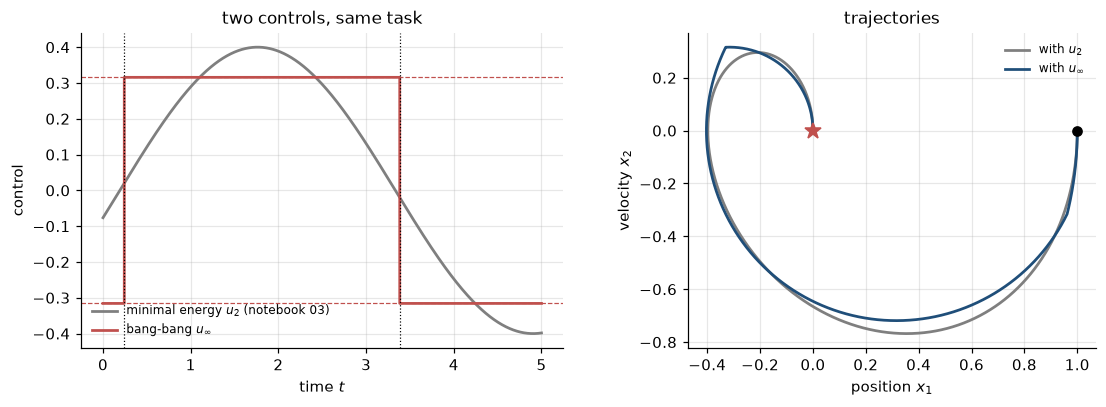

In [3]:
u_inf = lambda s: np.array([lam * signs[np.searchsorted(breaks, s, side="right") - 1 if s < T else -1]])
x_bb = simulate_piecewise(A, B, u_inf, x0, breaks, t)
x_2 = simulate_piecewise(A, B, gramian_control(A, B, T, x0, x1, gramian(A, B, T)), x0, [0.0, T], t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax1.plot(t, u_2, color=COLORS["reference"], label=r"minimal energy $u_2$ (notebook 03)")
ax1.step(t, sample(u_inf, t)[:, 0], where="post", color=COLORS["control"], label=r"bang-bang $u_\infty$")
for s in switches:
    ax1.axvline(s, color="black", lw=0.8, ls=":")
ax1.axhline(lam, color=COLORS["control"], lw=0.8, ls="--"); ax1.axhline(-lam, color=COLORS["control"], lw=0.8, ls="--")
ax1.set_xlabel("time $t$"); ax1.set_ylabel("control"); ax1.set_title("two controls, same task"); ax1.legend(fontsize=8, loc="lower left")
ax2.plot(x_2[:, 0], x_2[:, 1], color=COLORS["reference"], label="with $u_2$")
ax2.plot(x_bb[:, 0], x_bb[:, 1], color=COLORS["state"], label=r"with $u_\infty$")
ax2.plot(*x0, "o", color="black"); ax2.plot(*x1, "*", ms=11, color=COLORS["control"])
ax2.set_xlabel("position $x_1$"); ax2.set_ylabel("velocity $x_2$"); ax2.set_aspect("equal"); ax2.legend(fontsize=8)
ax2.set_title("trajectories")
plt.tight_layout(); plt.show()

**Figure 1.** Stopping E1 from $x^0=(1,0)$ at $T=5$ with one actuator. *Left:* the minimal-energy control $u_2=B^*\hat{\varphi}$ of notebook 03 and the bang-bang control $u_\infty=\lambda\operatorname{sgn}(B^*\hat{\varphi})$ obtained by minimizing $J_{bb}$. Dashed lines mark $\pm\lambda$, and dotted vertical lines mark the switching times. *Right:* the two trajectories.

*Interpretation (answer to the prediction).* The bang-bang control never exceeds $\lambda\approx0.316$, below the peak $\approx0.400$ of the minimal-energy control: Proposition 1 at work. It switches twice, at the two zeros of the observation $B^*\hat{\varphi}$ inside $(0,T)$, both sign-changing (zeros of a sinusoid are simple). The price is energy: $u_\infty$ is "on" all the time, so its $L^2$ norm exceeds that of $u_2$, as notebook 03 guarantees. Each control is optimal for its own norm.

## 5. Two actuators: switching controls
`CORE`

> **Two different structures.** *Bang-bang* (§§2–4) is structure in the **amplitude**: the control takes only the extreme values $\pm\lambda$. *Switching* is structure in **which actuator is active**: at each instant at most one actuator acts, with values that need not be extreme. Neither is a special case of the other; §6 shows how to combine them.

Now consider two scalar controls acting through vectors $b_1,b_2\in\mathbb R^n$ (p. 108):
$$
x'=Ax+u_1(t)\,b_1+u_2(t)\,b_2,\qquad x(0)=x^0 .
$$
In this section $u_1,u_2$ denote the controls of the two actuators. (The $L^2$-minimal control $u_2$ of §§2–4 does not appear here.)
Without constraints, the system is controllable if and only if the Kalman condition holds for $B=[b_1\ b_2]$ (p. 109). We look for **switching controls** (p. 109):

$$
u_1(t)\,u_2(t)=0\qquad\text{for almost every }t\in(0,T):
$$

**only one actuator acts at a time.** The classical functional $\tfrac12\int(|b_1\cdot\varphi|^2+|b_2\cdot\varphi|^2)$ gives the minimal-energy pair $u_i=b_i\cdot\hat{\varphi}$, and in general both are active simultaneously (p. 111). The slides introduce instead (p. 113)

$$
J_{sw}(\varphi_T)=\frac12\int_0^T\max\Big(|b_1\cdot\varphi(t)|^2,\ |b_2\cdot\varphi(t)|^2\Big)\,dt-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle .
\tag{SW}
$$

> **Theorem 2 (automatic switching; p. 113).**
> *Assumptions:* the pairs $(A,\,b_2-b_1)$ and $(A,\,b_2+b_1)$ satisfy the Kalman rank condition; $T>0$; and $x^1\ne e^{AT}x^0$ (otherwise $u=0$ works and there is nothing to switch).
> *Conclusion:* $J_{sw}$ attains its minimum at some $\tilde{\varphi}_T$, and the controls
> $$u_1(t)=\tilde{\varphi}(t)\cdot b_1\ \text{ where }|\tilde{\varphi}(t)\cdot b_1|>|\tilde{\varphi}(t)\cdot b_2|,\qquad u_2(t)=\tilde{\varphi}(t)\cdot b_2\ \text{ where }|\tilde{\varphi}(t)\cdot b_2|>|\tilde{\varphi}(t)\cdot b_1|,$$
> each set to zero elsewhere, steer $x^0$ to $x^1$, and they are of switching form.
> *Interpretation:* the minimizer decides at each instant which actuator "sees" the adjoint more strongly, and uses only that one.

**Why these rank conditions? A factorization.** The actuators tie, $|b_1\cdot\varphi|=|b_2\cdot\varphi|$, exactly when
$$
|b_1\cdot\varphi|^2-|b_2\cdot\varphi|^2=\big((b_1-b_2)\cdot\varphi\big)\big((b_1+b_2)\cdot\varphi\big)=0 .
$$
So the tie set is the union of the zero sets of the two observations $(b_2-b_1)\cdot\varphi$ and $(b_2+b_1)\cdot\varphi$. By the rank conditions, each of them is a nonzero analytic function when $\tilde{\varphi}_T\ne0$ (unique continuation for the pairs $(A,b_2\mp b_1)$). Each therefore has only finitely many zeros: **the switching set has measure zero**, and the controls are genuinely of switching form (pp. 114, 116). *(The factorization is a pedagogical addition that makes the role of the two rank conditions visible.)*

The rank conditions on $(A,b_2\pm b_1)$ imply controllability with the pair $(b_1,b_2)$, but not conversely. For instance, if $b_2=\pm b_1$, the actuators tie at every instant (p. 114).

**Existence and the control.** Coercivity follows from $|b_1\cdot\varphi|^2+|b_2\cdot\varphi|^2\le2\max(\cdot)$, which bounds $J_{sw}$ below by a functional equivalent to the classical one (p. 115). At the minimizer, the Euler–Lagrange equation reads (p. 117)
$$
\int_{S_1}(\tilde{\varphi}\cdot b_1)(\psi\cdot b_1)\,dt+\int_{S_2}(\tilde{\varphi}\cdot b_2)(\psi\cdot b_2)\,dt=\langle x^1,\psi_T\rangle-\langle x^0,\psi(0)\rangle\quad\forall\psi_T,
$$
with $S_i$ the set where actuator $i$ dominates. This is condition (C) for $u_i=(\tilde{\varphi}\cdot b_i)\mathbf 1_{S_i}$.

> **Remark on the source slides.** On p. 114 the system is written $x'+Ax=\dots$, while the rest of the section uses $x'=Ax+\dots$. We keep $x'=Ax+Bu$ throughout (`notation.md`).

> **Predict.** For E1 with two actuators, $b_1=(1,0)$ acting on the position and $b_2=(0,1)$ acting on the velocity, do you expect the optimal control to *mix* both actuators continuously, or to *select one at a time*? Compare with what the minimal-energy pair would do.

In [4]:
b1, b2 = np.array([1.0, 0.0]), np.array([0.0, 1.0])
B2 = np.column_stack([b1, b2])
print("Kalman ranks:  (A, b1):", kalman_rank(A, b1[:, None]), "  (A, b2):", kalman_rank(A, b2[:, None]),
      "  (A, b2-b1):", kalman_rank(A, (b2 - b1)[:, None]), "  (A, b2+b1):", kalman_rank(A, (b2 + b1)[:, None]))

result_sw = minimize(lambda p: switching_functional(A, b1, b2, T, x0, x1, p)[:2], x0=np.array([0.1, -0.1]),
                     jac=True, method="BFGS", options={"gtol": 1e-12})
assert result_sw.success, result_sw.message
J_sw_min, grad_sw, ties, active = switching_functional(A, b1, b2, T, x0, x1, result_sw.x)
phi_T_sw = result_sw.x
sw_breaks = np.concatenate([[0.0], ties, [T]])


def u_switching(s):
    # u_i = (phi(s) . b_i) on the pieces where actuator i dominates, 0 otherwise
    j = min(np.searchsorted(sw_breaks, s, side="right") - 1, len(active) - 1)
    phi_s = adjoint_trajectory(A, phi_T_sw, [s], T)[0]
    u = np.zeros(2)
    u[active[j]] = phi_s @ (b1, b2)[active[j]]
    return u


x_sw = simulate_piecewise(A, B2, u_switching, x0, sw_breaks, t)
U_sw = sample(u_switching, t)
U_l2 = sample(gramian_control(A, B2, T, x0, x1, gramian(A, B2, T)), t)      # minimal-energy pair

print(f"\noptimizer: success = {result_sw.success}, |grad J_sw| = {np.linalg.norm(grad_sw):.1e}")
print(f"switching times: {ties}   active actuator on each piece: {active + 1}   number of switches: {len(ties)}")
print(f"max_t |u1(t) u2(t)|  switching control: {np.abs(U_sw[:, 0] * U_sw[:, 1]).max():.1e}"
      f"   minimal-energy pair: {np.abs(U_l2[:, 0] * U_l2[:, 1]).max():.2f}")
print(f"terminal error |x(T) - x1| = {np.linalg.norm(x_sw[-1] - x1):.1e}")

Kalman ranks:  (A, b1): 2   (A, b2): 2   (A, b2-b1): 2   (A, b2+b1): 2



optimizer: success = True, |grad J_sw| = 4.0e-16
switching times: [0.77499 2.34578 3.91658]   active actuator on each piece: [1 2 1 2]   number of switches: 3
max_t |u1(t) u2(t)|  switching control: 0.0e+00   minimal-energy pair: 0.02
terminal error |x(T) - x1| = 2.1e-10


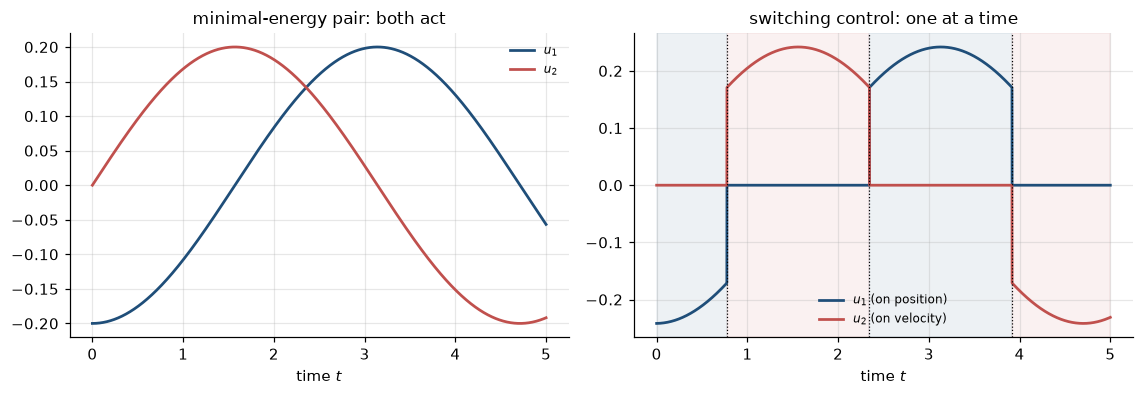

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7))
axes[0].plot(t, U_l2[:, 0], color=COLORS["state"], label="$u_1$")
axes[0].plot(t, U_l2[:, 1], color=COLORS["control"], label="$u_2$")
axes[0].set_title("minimal-energy pair: both act"); axes[0].set_xlabel("time $t$"); axes[0].legend(fontsize=8)

axes[1].plot(t, U_sw[:, 0], color=COLORS["state"], label="$u_1$ (on position)")
axes[1].plot(t, U_sw[:, 1], color=COLORS["control"], label="$u_2$ (on velocity)")
for (a, b), i in zip(zip(sw_breaks[:-1], sw_breaks[1:]), active):
    axes[1].axvspan(a, b, color=(COLORS["state"], COLORS["control"])[i], alpha=0.08)
for s in ties:
    axes[1].axvline(s, color="black", lw=0.8, ls=":")
axes[1].set_title("switching control: one at a time"); axes[1].set_xlabel("time $t$"); axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**Figure 2.** E1 with two actuators, $b_1=(1,0)$ and $b_2=(0,1)$, stopping the oscillator from $x^0=(1,0)$ at $T=5$. *Left:* the minimal-energy pair, which uses both actuators at all times. *Right:* the switching control from $J_{sw}$; shaded bands show the active actuator, and dotted lines the switching times. The printed terminal error confirms that it reaches the target.

*Interpretation (answer to the prediction).* The minimizer of $J_{sw}$ selects one actuator at a time, $u_1u_2=0$ up to rounding, and switches three times. The pieces alternate between position and velocity actuation, following which component of the rotating adjoint is larger. Within each piece the control is a smooth sinusoid, not bang-bang: $J_{sw}$ imposes structure on *which actuator* acts, not on the amplitude. Figures 1 and 2 together separate the three cases: minimal energy (no structure), bang-bang (amplitude), switching (actuator). Combining both requirements gives the switching bang-bang controls of §6.

## 6. Details: analyticity, differentiability and variants
`DEEPER LOOK`

**Differentiability of $N$ and of $J_{sw}$.** For $\varphi_T$ with $B^*\varphi$ vanishing only on a null set, $\frac1h\big(|B^*\varphi+hB^*\psi|-|B^*\varphi|\big)\to\operatorname{sgn}(B^*\varphi)B^*\psi$ almost everywhere as $h\to0$. The quotients are bounded by $|B^*\psi|$, so dominated convergence gives the derivative of §3. The same argument applies to $\max(|b_1\cdot\varphi|^2,|b_2\cdot\varphi|^2)$ away from the tie set. When the minimizer is computed numerically, the switching times are located exactly (sign changes followed by bisection), and the integrals are split there, so the computed gradient is that of the exact functional (`src/control_utils.py`).

**The analyticity argument (p. 116).** The tie set is the union of the zero sets of the scalar analytic functions $\tilde{\varphi}\cdot(b_2-b_1)$ and $\tilde{\varphi}\cdot(b_2+b_1)$ (§5). If either zero set had positive measure, that function would vanish identically, and the rank condition for $(A,b_2-b_1)$, respectively $(A,b_2+b_1)$, would force $\tilde{\varphi}_T=0$. These two rank conditions are exactly the hypotheses of Theorem 2. Then $J_{sw}(\varphi_T)\ge0=J_{sw}(0)$ for all $\varphi_T$, which happens only in the trivial case $x^1=e^{AT}x^0$ (p. 116).

**Preassigned switching (p. 112).** Given a partition $0=t_0<t_1<\dots<t_{2N}=T$, the functional
$$J_\tau=\tfrac12\sum_j\int_{t_{2j}}^{t_{2j+1}}|b_1\cdot\varphi|^2+\tfrac12\sum_j\int_{t_{2j+1}}^{t_{2j+2}}|b_2\cdot\varphi|^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$$
is coercive under the same rank condition, by time-analyticity. It gives switching controls with switching times chosen *in advance*. $J_{sw}$ instead chooses them *automatically*.

**Switching bang-bang (pp. 119–120).** Minimizing $\tfrac12\big(\int_0^T\max(|b_1\cdot\varphi|,|b_2\cdot\varphi|)\big)^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$ gives $u_i=\lambda\,\operatorname{sgn}(\tilde{\varphi}\cdot b_i)\mathbf 1_{S_i}$, with $\lambda=\int\max(|\tilde{\varphi}\cdot b_1|,|\tilde{\varphi}\cdot b_2|)$. These controls are bang-bang *and* switching, and they have minimal $L^\infty(0,T;\mathbb R^2)$ norm. The switching controls of $J_{sw}$ are minimal in $L^2(0,T;\mathbb R^2)$, with $\mathbb R^2$ carrying the $\ell^1$ norm (p. 120).

## 7. Switching beyond the actuators
`RESEARCH WINDOW`

The slides also mention systems in which the **dynamics itself switches**, $x'=A(t)x+u_1b_1+u_2b_2$ with $A(t)\in\{A_1,\dots,A_M\}$ (p. 108). Controllability and the design of the switching rule then interact with the switching of the state matrix, and the simple factorization of §5 is no longer available. Piecewise-constant controls and the *number of switches* reappear later in the course as a measure of complexity. In the classification results for neural ODEs, the controls are piecewise constant with $O(N)$ switches for $N$ data points (p. 338), the subject of [notebook 14](14_classification_as_simultaneous_control.ipynb).

## 8. Control ↔ ML: switches and layers
`CORE` · **FORWARD CONNECTION**

In the neural-ODE reading of residual networks ([notebook 13](13_resnets_neural_odes.ipynb)), a control that is piecewise constant in time corresponds to a network whose parameters stay fixed within a block of layers, so that **each time discontinuity corresponds to one change of layer** (p. 339). Counting switches, as in Figures 1–2, will become a way of counting the *depth* needed for a task (notebooks [13](13_resnets_neural_odes.ipynb) and [14](14_classification_as_simultaneous_control.ipynb)). This is an architectural precursor, not an identity: it holds for the neural-ODE model of a network, and the switching controls of §5 are not themselves networks.

**MATHEMATICAL ANALOGY.** The duality between $L^1$ on the observation and $L^\infty$ on the control (§4) has a cousin in the $\ell^1$-sparse training of shallow networks ([notebook 12](12_shallow_networks_representation_sparsity.ipynb)). The structures are similar, not identical.

## 9. Common misconceptions
`CORE`

**"Bang-bang controls are crude, so they must be suboptimal."** They are optimal for the right criterion: no control reaching the target has smaller amplitude (Proposition 1).

**"Switching controls are bang-bang."** Not necessarily. $J_{sw}$ gives one actuator at a time, with smooth values on each piece (Figure 2). Bang-bang *and* switching requires the functional of §6.

**"Controllability with two actuators guarantees switching controls."** The theorem needs the stronger rank conditions on $(A,b_2\pm b_1)$; for $b_2=\pm b_1$ they fail.

## 10. What you should remember
`CORE`

1. Structured controls answer practical limits: bounded amplitude, on/off actuators, one actuator at a time.
2. Changing the first term of the dual functional changes the structure of the control; the adjoint and condition (C) stay the same.
3. $J_{bb}=\tfrac12\big(\int|B^*\varphi|\big)^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$ gives $u_\infty=\lambda\operatorname{sgn}(B^*\hat{\varphi})$, switching at the sign-changing zeros of the observation.
4. $\lambda=\|u_\infty\|_{L^\infty}$ is the smallest amplitude of any control, by Hölder's inequality ($L^1$ observation ↔ $L^\infty$ control), and $\min J_{bb}=-\tfrac12\lambda^2$.
5. $J_{sw}$, with a $\max$ over two actuators, gives switching controls, $u_1u_2=0$.
6. The tie set is where $\big((b_1-b_2)\cdot\varphi\big)\big((b_1+b_2)\cdot\varphi\big)=0$; the rank conditions on $(A,b_2\pm b_1)$ make it finite.

## 11. Exercises

★ conceptual · ★★ mathematical · ★★★ computational. `FIRST PASS` exercises are the minimum route; `STANDARD` ones consolidate the notebook; `ADVANCED` ones are optional. Reference solutions are kept in a separate instructor notebook. Try first.

**Exercise 1 ★★ (deriving the bang-bang structure)** · `FIRST PASS`. (a) From the optimality condition of §3, explain why $u_\infty$ takes only the values $\pm\lambda$ and switches exactly at the sign-changing zeros of $B^*\hat\varphi$. Which assumptions guarantee that there are only finitely many switches? (b) For E1 with one actuator, show that the observation of any adjoint solution has the form $B^*\varphi(t)=\rho\sin(T-t+\theta)$ with $\rho=|\varphi_T|$. Deduce that the bang-bang control switches at most $\lceil T/\pi\rceil$ times on $(0,T)$, and that consecutive switching times are exactly $\pi$ apart. Check against the lab.

**Exercise 2 ★ (amplitude or actuator?)** · `FIRST PASS`. (a) For each of the three functionals in the table of "Where are we?", say whether the resulting control has structure in its *amplitude*, in the *choice of actuator*, or neither. (b) What structure do you expect from minimizing $\tfrac12\big(\int_0^T\max(|b_1\cdot\varphi|,|b_2\cdot\varphi|)\,dt\big)^2-\langle x^1,\varphi_T\rangle+\langle x^0,\varphi(0)\rangle$? (c) Why is the classical two-actuator functional of p. 111 unable to produce switching controls in general?

**Exercise 3 ★★ (amplitude and time)** · `STANDARD`. Let $\lambda(T)$ be the bang-bang amplitude for steering $x^0$ to $x^1=0$ in time $T$. (a) Using Proposition 1, prove that $\lambda(T')\le\lambda(T)$ for $T'>T$. *Hint:* the origin is an equilibrium of the free system. (b) Deduce that for an actuator bound $U$, the set of times in which the target can be reached with $|u|\le U$ is an interval $[T^*(U),\infty)$, provided it is nonempty and closed.

**Exercise 4 ★★ (when switching fails)** · `STANDARD`. Take $b_2=b_1$. (a) Which rank condition of Theorem 2 fails? (b) Show that $J_{sw}$ reduces to the one-actuator HUM functional and that $|b_1\cdot\varphi|=|b_2\cdot\varphi|$ at *every* time. (c) Is the system still controllable with the pair $(b_1,b_2)$? Is the decomposition of a control into $u_1$ and $u_2$ unique?

**Exercise 5 ★★★ (the amplitude–time trade-off)** · `ADVANCED`. Using `bang_bang_functional`, compute the bang-bang amplitude $\lambda(T)$ for stopping E1 from $x^0=(1,0)$, for $T\in[1,15]$. Plot $\lambda(T)$, check numerically that it is non-increasing (Exercise 3), and estimate the minimal time $T^*(U)$ for the actuator bound $U=0.2$.

In [6]:
# TODO: student exercise (Exercise 5)
# For each T in a grid on [1, 15], minimize J_bb with scipy.optimize.minimize (jac=True, as in the lab)
# and record lambda(T). Then plot lambda(T) and find the smallest T with lambda(T) <= 0.2.

def bang_bang_amplitude(T_):
    ...  # your code here
    return None

## Where are we going?
`CORE`

Notebooks 02–04 built **open-loop** controls: functions of time, computed in advance from the model. [Notebook 05](05_feedback_stabilization.ipynb) turns to **closed-loop** control, where the control is computed from the current state. There, observability returns in a new role: it gives the decay rate of a stabilizing feedback. The minimization principles used here are studied in their own right in [notebook 06](06_variational_principles_gradient_flows.ipynb).

## Source map
`CORE`

All page numbers are PDF pages of `CML_slides_20250520.pdf`; the machine-readable version is `source_map.csv`.

| Section | PDF pages | Content in the slides |
|---|---|---|
| §1 Why structured controls | 110, 132 | Switching form; "there are very many controls" |
| §2 Bang-bang functional | 103 | $J_{bb}$, continuity and coercivity |
| §3 Optimality condition | 104 | Euler–Lagrange equation, bang-bang control, finitely many switches |
| §4 $L^\infty$-minimality | 105–107 | Proposition and proof |
| §5 Switching | 108–117 | Two actuators; rank condition; $u_1u_2=0$; classical and new functionals; theorem; necessity of the rank conditions; coercivity; null switching set; Euler–Lagrange |
| §6 Details and variants | 112, 116, 119–120 | Preassigned switching; analyticity; switching bang-bang and optimality |
| §7 Switching dynamics | 108, 338 | $A(t)\in\{A_1,\dots,A_M\}$; $O(N)$ switches for classification |
| §8 Switches and layers | 339 | Each time discontinuity ∼ one change of layer |

The source-map rows also record the pedagogical additions (the table of functionals, the existence argument by equivalence of norms, the dual-norm reading of minimality, the factorization of the tie set, Figures 1–2) and the remarks on the source slides (pp. 103–104, 114).